### Improving grpo for reinforcement learning--->  rlvr

In [ ]:
from pathlib import Path
import sys
import torch

ROOT_DIR = Path.cwd().parent  # Get parent of current directory
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))


from evaluating_reasoning_models.model_and_tokenizer import load_model_and_tokenizer

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    use_compile=False,
    load_rlvr_checkpoint=True
)


#### downloading previous chapter notebook

In [1]:
from pathlib import Path
import requests


def download_from_github(rel_path, out=None):

    github_raw_base = (
        "https://raw.githubusercontent.com/"
        "shaheennabi/open-posttraining-system/main/"
    )

    rel_path = Path(rel_path)

    out = Path(out) if out is not None else Path(rel_path.name)

    if out.exists():
        print(f"{out} already exists")
        return out

    r = requests.get(
        github_raw_base + rel_path.as_posix()
    )
    r.raise_for_status()

    out.write_bytes(r.content)

    print(f"Downloaded {out}")

    return out

In [2]:
download_from_github(
    "training_reasoning_models_with_reinforcement_learning/rlvr_grpo_training_with_no_kl.py"
)

rlvr_grpo_training_with_no_kl.py already exists


PosixPath('rlvr_grpo_training_with_no_kl.py')

In [ ]:
### rlvr_grpo training run
!uv run rlvr_grpo_training_with_no_kl.py --steps 500 --max_new_tokens 1024

In [3]:
## log file (download from previous chapter)
download_from_github(
    "training_reasoning_models_with_reinforcement_learning/train_rlvr_grpo_metrics.csv"
)

train_rlvr_grpo_metrics.csv already exists


PosixPath('train_rlvr_grpo_metrics.csv')

In [4]:
import pandas as pd

df = pd.read_csv(
    "train_rlvr_grpo_metrics.csv",
    header=None,
    names=[
        "step",
        "eval_freq",
        "loss",
        "reward_avg",
        "avg_response_len",
    ],
)

print(df.head())

   step  eval_freq      loss  reward_avg  avg_response_len
0     1         50 -1.239144        0.25            287.75
1     2         50 -3.203884        0.25            295.00
2     3         50 -0.000000        1.00            152.25
3     4         50 -0.000000        1.00            129.00
4     5         50 -5.945770        0.75            143.50


#### Inspecting the grpo training run (from sebastian raschka's notebook)

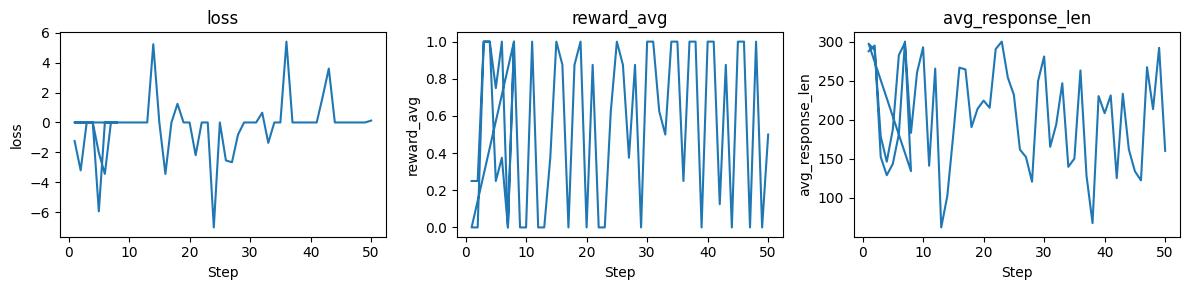

In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv(
    "train_rlvr_grpo_metrics.csv",
    header=None,
    names=[
        "step",
        "eval_freq",
        "loss",
        "reward_avg",
        "avg_response_len",
    ],
)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

metrics = [
    "loss",
    "reward_avg",
    "avg_response_len",
]

for ax, metric in zip(axes, metrics):
    ax.plot(df["step"], df[metric])
    ax.set_title(metric)
    ax.set_xlabel("Step")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

In [ ]:
from evaluating_reasoning_models.load_math_500 import load_math500_test
eval_data = load_math500_test()

In [ ]:
## ### on rlvr_grpo checkpoint(8 rollouts  ---> 50 steps)--> 
from evaluating_reasoning_models.evaluating_reasoning_models import evaluate_math500_stream

math_eval = eval_data[:50]  ## last 50 problems of math_dataset...

device = "cuda" if torch.cuda.is_available() else "cpu"
## evaluation function
num_correct, num_examples, acc = evaluate_math500_stream(model, tokenizer, device, math_eval, max_new_tokens=2048, verbose=False)




### Tracking more advanced Grpo performance metrics

* Advantage tracking

* Entropy tracking